# Project: Visualizing The Stock Market: Decoding the S&P 500

> *"We search through historical data to find anomalies... We don't start with models. We start with data."* — **Jim Simons**, Mathematician, Philantrophist & Founder of Renaissance Technologies.

---

### The Mission
Welcome, Analyst. You are no longer just a student; today, you are a quantitative researcher entering the high-dimensional arena of the S&P 500. 

In the world of elite hedge funds, the market is not viewed as a simple list of stock prices. It is seen as a chaotic, breathing ecosystem of **signals buried in mountains of noise.** The legends of the field (Jim Simons, Ken Griffin, Ray Dalio) didn't build their empires by following the news. They built them by developing a "visual intuition" for the invisible structures that govern the global economy.

### The Challenge
How do you visualize 500 companies moving simultaneously across thousands of days? How do you see the "DNA" of a sector or the hidden gravitational pull that one stock exerts on another? 

This project is designed to take you from raw data ingestion to the **Frontier of Alpha**. Over the course of this notebook, you will:

1.  **Ingest the Pulse:** Stream 5 years of market-wide data, learning to spot the "gaps" where information is lost.
2.  **Expose the Skeleton:** Use hierarchical clustering to reveal the "tribes" of the market—seeing how stocks group together regardless of their official sector labels.
3.  **Warp Dimensions:** Apply advanced dimensionality reduction techniques: **PCA (Principal Component Analysis)** and **t-SNE**, to compress a 500-dimensional market into a 2D "map" you can actually navigate.

### The Goal
By the end of this investigation, you won't just see a line chart. You will see the **latent clusters** and **anomalous outliers** that the rest of the market is blind to. You are about to build a "GPS" for the financial markets.

**First, use the following code snippet to set a plot style close to those used in financial markets.**

---

In [1]:
%pip install -U lxml html5lib


Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -U nbformat ipython

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

# Setting a dark, high-contrast theme for that "Trading Floor" feel
plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

# For interactive Plotly charts, we use a dark template
pio.templates.default = "plotly_dark"

## Part 1: Getting and cleaning the data

**The Objective:** 
In quantitative finance, your model is only as good as your data—a concept known as *Garbage In, Garbage Out*. A true Quant doesn't just download a CSV; they investigate the "health" of their data before a single trade is placed. 

In this part, you will fetch the daily historical data for the current S&P 500 constituents. While it is tempting to use a small subset, we want to see the *entire* universe to understand systemic risk. We will use the `yfinance` library to scrape this data from the web.

### Your Tasks:
1.  **Retrieve Tickers:** Programmatically retrieve the list of current S&P 500 tickers (Hint: Wikipedia's "List of S&P 500 companies" table is the industry-standard source for this).
2.  **Download Historical Data:** Download the last **5 years** of daily data for these tickers. Focus specifically on the **Adjusted Close** price. 
    *   *Note: Downloading 500+ tickers may take a few minutes. If your hardware is struggling, you may choose to proceed with a subset (e.g., the first 100 tickers), but try for the full set first!*
3.  **Visualize Data Completeness:** Create a "Missingness Map" or a "Data Integrity Heatmap." In finance, missing data is often a "trap" (e.g., a company was delisted, merged, or newly added). You need to visualize which stocks have gaps or incomplete histories.

### Critical Thinking Questions:
*   **Price vs. Adjusted Price:** Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns? (Hint: Think about dividends and stock splits).
*   **The Survival Bias:** By downloading data for the *current* S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?
*   **The Imputation Dilemma:** If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

---

In [4]:
########## Write the rest of your code for Part 3 in this cell ############

Fetching S&P 500 ticker list...
Error fetching tickers from Wikipedia: [Errno 2] No such file or directory: <!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>List of S&amp;P 500 companies - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-fe

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
$WBA: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IPG"}}}
$IPG: possibly delisted; no timezone found
$FI: possibly delisted; no timezone found

3 Failed downloads:
['WBA', 'IPG', 'FI']: possibly delisted; no timezone found


Dropping all-NaN tickers (failed downloads): ['FI', 'IPG', 'WBA']
raw_data shape: (1254, 500)
Top 10 most-missing tickers:
Ticker
GEV     0.625997
SOLV    0.625199
VLTO    0.530303
KVUE    0.446571
GEHC    0.370813
CEG     0.188198
COIN    0.033493
K       0.031898
DAY     0.003190
NCLH    0.000000
dtype: float64


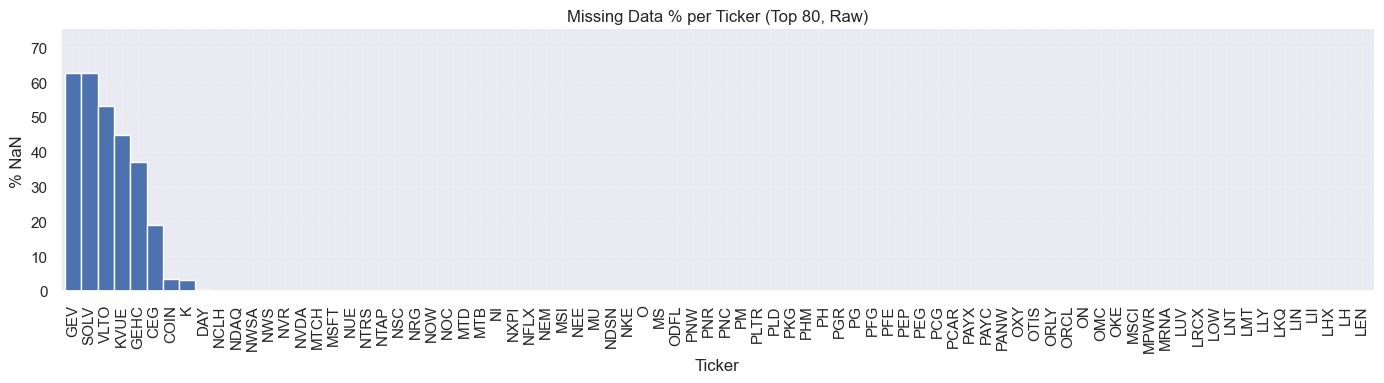

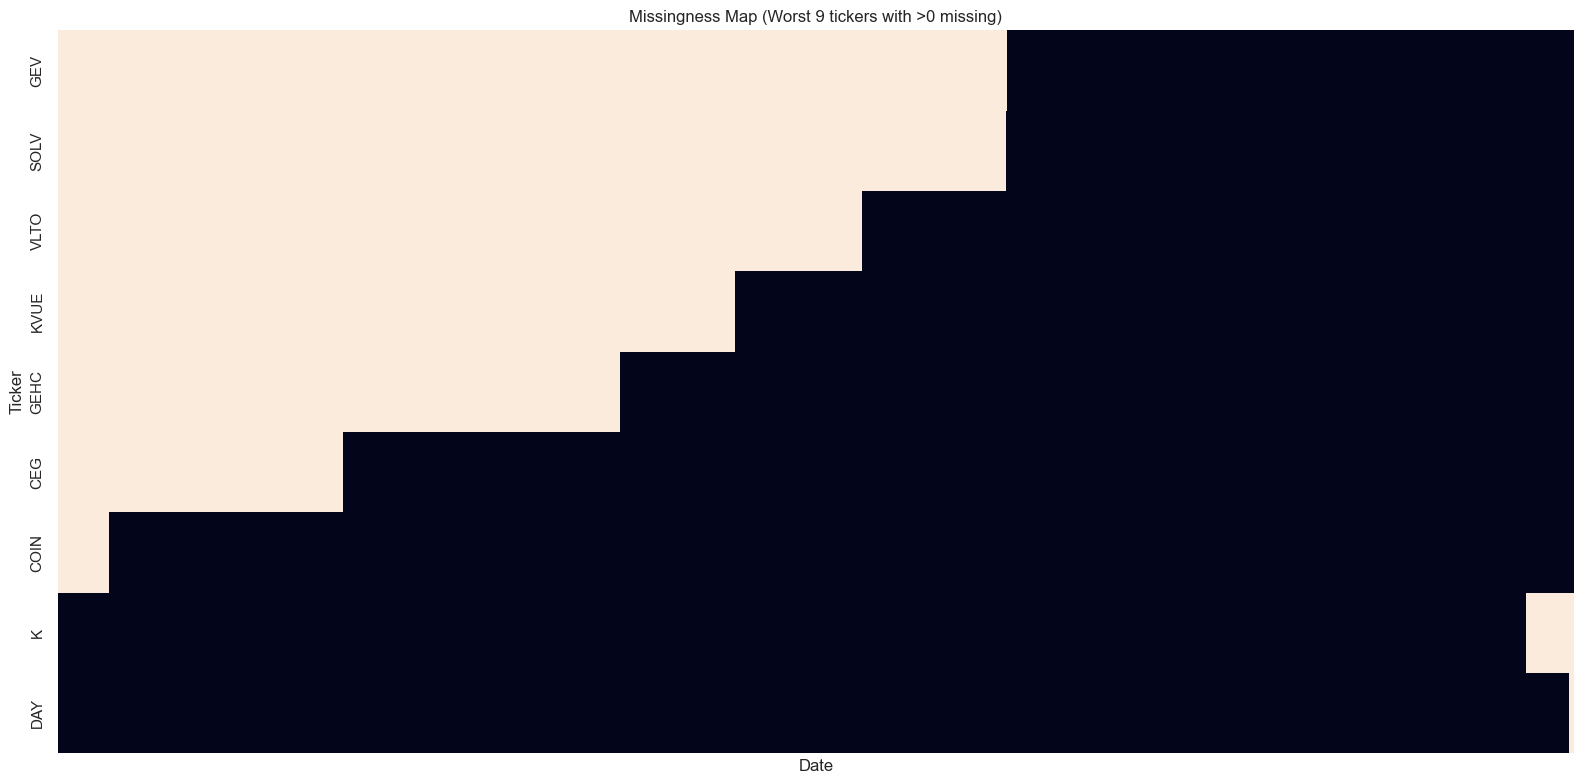

prices shape after cleaning: (1254, 496)
Unknown sector mappings: 0


In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# -----------------------------
# 1) Retrieve S&P 500 tickers (Wikipedia preferred)
# -----------------------------
print("Fetching S&P 500 ticker list...")
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/91.0.4472.124 Safari/537.36"
    )
}

sp500_df = None
try:
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()
    table_list = pd.read_html(response.text)
    sp500_df = table_list[0]

    # Expected columns from Wikipedia table
    if "Symbol" not in sp500_df.columns:
        raise ValueError("Wikipedia table did not contain 'Symbol' column as expected.")

    tickers = sp500_df["Symbol"].tolist()
    print(f"Successfully retrieved {len(tickers)} tickers from Wikipedia.")

except Exception as e:
    print(f"Error fetching tickers from Wikipedia: {e}")
    print("Falling back to a public S&P 500 constituents CSV (full list).")

    # Fallback that still gives the FULL S&P 500 universe (not the tiny subset)
    csv_url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
    sp500_df = pd.read_csv(csv_url)  # columns: Symbol, Name, Sector
    sp500_df = sp500_df.rename(columns={"Sector": "GICS Sector"})

    if "Symbol" not in sp500_df.columns or "GICS Sector" not in sp500_df.columns or len(sp500_df) < 450:
        print("Fallback CSV did not load correctly. Using tiny subset as last resort.")
        tickers = [
            "AAPL", "MSFT", "NVDA", "AMD", "GOOG", "META",  # Big Tech
            "JPM", "BAC", "GS", "MS", "WFC",               # Banks
            "XOM", "CVX", "COP", "SLB",                    # Energy
            "JNJ", "PFE", "MRK", "LLY",                    # Pharma
            "KO", "PEP", "PG", "WMT", "COST",              # Consumer Staples
            "BA", "CAT", "LMT",                            # Industrial
            "NEE", "DUK"                                   # Utilities
        ]
        sp500_df = None
    else:
        tickers = sp500_df["Symbol"].tolist()
        print(f"Successfully retrieved {len(tickers)} tickers from fallback CSV.")


# Yahoo Finance uses '-' instead of '.' for tickers like BRK.B
tickers = [t.replace(".", "-") for t in tickers]

# Build ticker -> sector map (used in Part 2/4). Works for Wikipedia + fallback CSV.
if sp500_df is not None:
    # Ensure we map Yahoo-style tickers (with '-' not '.')
    sp500_df["yf_ticker"] = sp500_df["Symbol"].astype(str).str.replace(".", "-", regex=False)

    # Wikipedia uses "GICS Sector"; fallback CSV renamed to "GICS Sector" above.
    if "GICS Sector" in sp500_df.columns:
        ticker_to_sector = dict(zip(sp500_df["yf_ticker"], sp500_df["GICS Sector"]))
    else:
        ticker_to_sector = {t: "Unknown" for t in tickers}
else:
    ticker_to_sector = {t: "Unknown" for t in tickers}


# -----------------------------
# 2) Download 5 years of historical data
# -----------------------------
print(f"Downloading data for {len(tickers)} tickers. This may take a moment...")
end_date = datetime.now()
start_date = end_date - timedelta(days=5 * 365)

dl = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    threads=True,
    progress=False
)

# Extract Adj Close robustly (and fall back to Close if needed)
if isinstance(dl.columns, pd.MultiIndex):
    # MultiIndex like (Field, Ticker)
    if "Adj Close" in dl.columns.get_level_values(0):
        raw_data = dl["Adj Close"]
    elif "Close" in dl.columns.get_level_values(0):
        raw_data = dl["Close"]
    else:
        raise KeyError("Neither 'Adj Close' nor 'Close' found in downloaded data.")
else:
    # Single-index (rare here, but safe)
    if "Adj Close" in dl.columns:
        raw_data = dl["Adj Close"].to_frame()
    elif "Close" in dl.columns:
        raw_data = dl["Close"].to_frame()
    else:
        raise KeyError("Neither 'Adj Close' nor 'Close' found in downloaded data.")

# Drop tickers that completely failed (all NaN)
failed = raw_data.columns[raw_data.isna().all()].tolist()
if failed:
    print("Dropping all-NaN tickers (failed downloads):", failed)
    raw_data = raw_data.drop(columns=failed)

print("raw_data shape:", raw_data.shape)


# -----------------------------
# 3) Missingness inspection (Part 1 visuals)
# -----------------------------
missing_frac = raw_data.isna().mean().sort_values(ascending=False)

print("Top 10 most-missing tickers:")
print(missing_frac.head(10))

topN = min(80, len(missing_frac))
plt.figure(figsize=(14, 4))
(missing_frac.head(topN) * 100).plot(kind="bar", width=1.0)
plt.title(f"Missing Data % per Ticker (Top {topN}, Raw)")
plt.ylabel("% NaN")
ymax = float((missing_frac.head(topN) * 100).max())
plt.ylim(0, max(0.05, ymax * 1.2))  # visible even if missingness is tiny
plt.tight_layout()
plt.show()

nonzero = missing_frac[missing_frac > 0].index
N = min(60, len(nonzero))
if N == 0:
    print("No missing values detected (all missing fractions are 0). Heatmap would be uniform.")
else:
    worst = nonzero[:N]
    plt.figure(figsize=(16, 8))
    sns.heatmap(raw_data[worst].isna().T, cbar=False)
    plt.title(f"Missingness Map (Worst {N} tickers with >0 missing)")
    plt.xlabel("Date")
    plt.ylabel("Ticker")
    plt.xticks([])
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) Produce cleaned 'prices' for later parts
#    (minimal cleaning: trim dates w/ broad coverage + keep tickers w/ enough history)
# -----------------------------
# Optional: keep only dates where >=90% tickers exist (reduces “triangle” missingness)
coverage = raw_data.notna().mean(axis=1)
prices_work = raw_data.loc[coverage >= 0.90].copy()

# Keep tickers with >=60% observations within the trimmed window
min_obs = int(0.60 * len(prices_work))
keep_cols = prices_work.count() >= min_obs
prices = prices_work.loc[:, keep_cols].copy()

# Fill remaining small gaps (forward/back)
prices = prices.ffill().bfill()

print("prices shape after cleaning:", prices.shape)
print("Unknown sector mappings:", sum(v == "Unknown" for v in ticker_to_sector.values()))


In [6]:
print("len(tickers):", len(tickers))
print("raw_data cols:", raw_data.shape[1])
print("prices cols:", prices.shape[1])
print("Unknown sectors:", sum(v == "Unknown" for v in ticker_to_sector.values()))


len(tickers): 503
raw_data cols: 500
prices cols: 496
Unknown sectors: 0


## Part 2: Volatility & Risk

**The Objective:** 
In the world of quantitative trading, **Price is a liar.** A $10 move in a $100 stock is massive; a $10 move in a $3,000 stock is noise. To compare apples to apples, Quants transform prices into **Log Returns** or **Percentage Returns**. This process, known as making the data "stationary," allows us to apply statistical models.

In this section, you will stop looking at how much a stock is *worth* and start looking at how much it *moves*. We will explore "Volatility" (the heartbeat of the market) and visualize the distribution of returns to see if the market truly follows a "Normal Distribution" (spoiler: it usually doesn't).

### Your Tasks:
1.  **Calculate Daily Returns:** Convert your cleaned price dataframe into daily percentage changes. 
2.  **The Heartbeat (Volatility Map):** Calculate the rolling 30-day standard deviation (volatility) for the entire S&P 500. Create a visualization that compares the volatility of different **Sectors** (e.g., are Tech stocks objectively "shakier" than Consumer Staples?).
3.  **The Distribution of Fear:** Plot a Histogram of the daily returns for the S&P 500 index. Overlay a "Normal Distribution" curve over it (hint: use the mean and the standard deviation of the whole dataset). 
4.  **Interactive Deep Dive:** Use `Plotly` to create a professional-grade interactive Candlestick chart for a few high-profile stocks (e.g., NVDA, TSLA, or MSFT). Include a subplot for **Volume** to see if price moves are backed by "conviction."

### Critical Thinking Questions:
*   **The Fat Tail Problem:** When you look at the Histogram of returns, do the "tails" (the extreme ends) match the Normal Distribution curve? If the "tails" are thicker (Kurtosis), what does that imply about the frequency of market crashes versus what standard statistics predict?
*   **Volatility Clustering:** Look at a time-series plot of returns (pick a stock of your choice). Do you notice that "calm" periods are followed by calm, and "volatile" periods are followed by volatile ones? This is a famous phenomenon. How would a trader use this information?
*   **The Volume Signal:** In your candlestick chart, look for a day with a massive price move. Was the Volume higher than average that day? Why do Quants say "Volume precedes price"?

---

Returns shape: (1253, 496)

Sector counts (sanity check):
Sector
Industrials               76
Financials                73
Information Technology    68
Health Care               59
Consumer Discretionary    51
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64


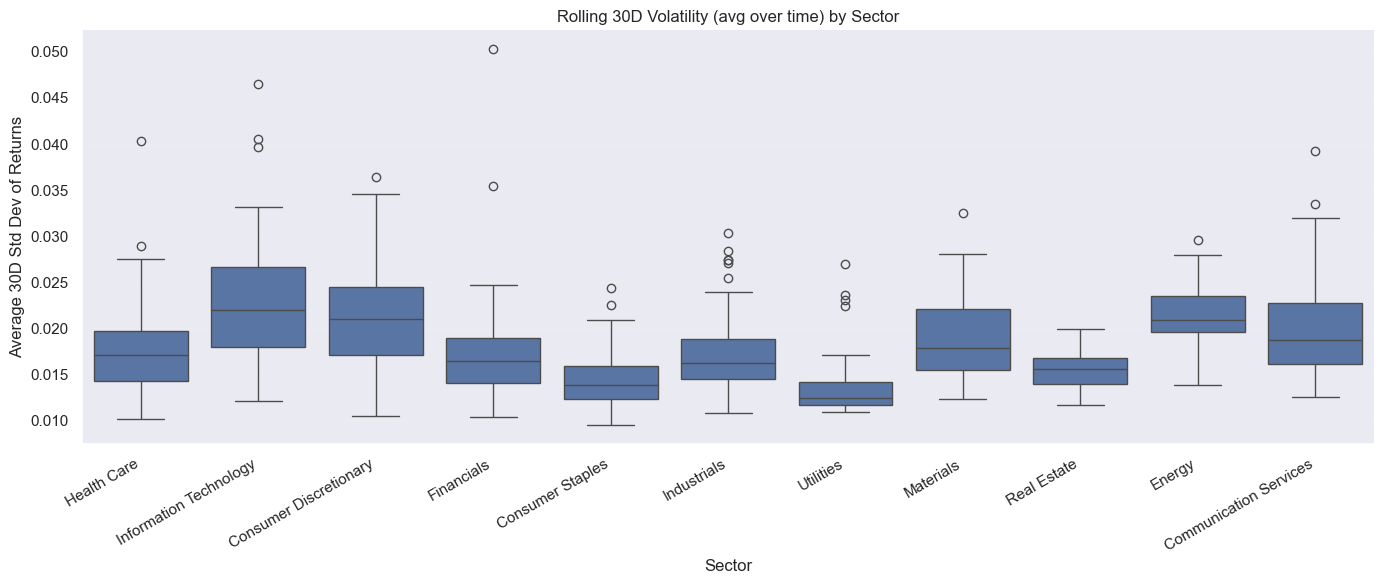

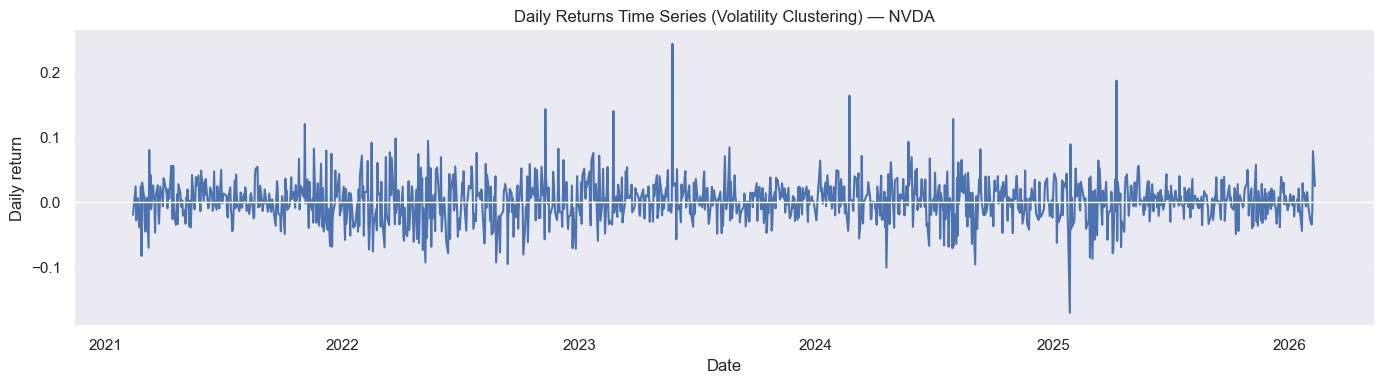

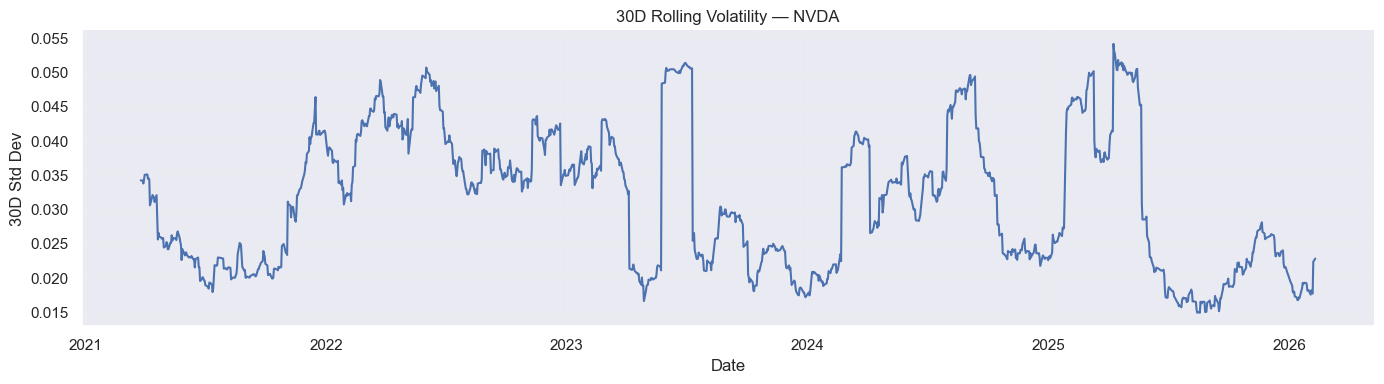

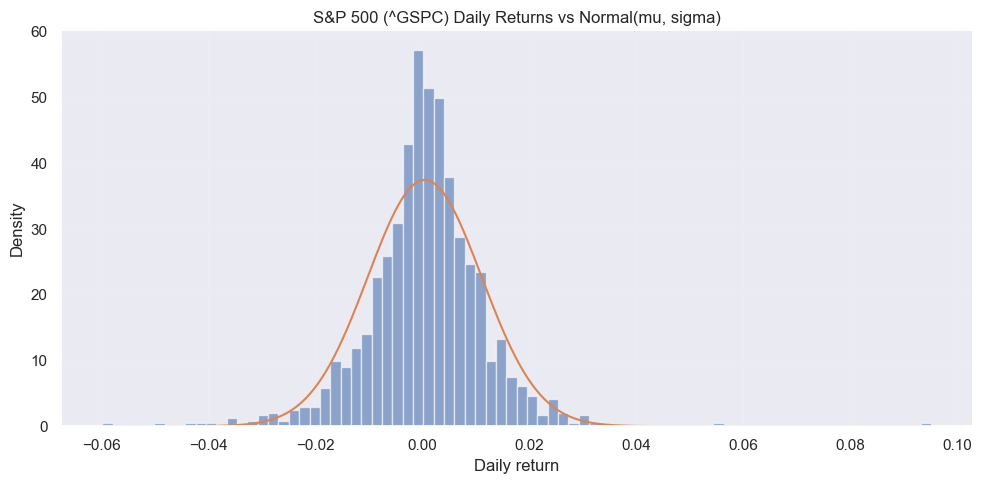

In [7]:
########## Write your code in this cell ############

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------
# Sanity checks (Part 1 outputs)
# -----------------------------
assert "prices" in globals(), "Part 1 variable 'prices' not found. Run Part 1 first."
assert "start_date" in globals() and "end_date" in globals(), "Part 1 'start_date'/'end_date' not found. Run Part 1 first."

# -----------------------------
# Helpers
# -----------------------------
def extract_price_series(df: pd.DataFrame, ticker: str | None = None) -> pd.Series:
    """
    Robustly extract a 1D price series from a yfinance download result.
    Prefers 'Adj Close', falls back to 'Close'. Handles MultiIndex columns.
    """
    if df is None or df.empty:
        raise ValueError("Empty DataFrame returned from yfinance.")

    # MultiIndex case
    if isinstance(df.columns, pd.MultiIndex):
        if ticker is not None:
            # Case A: (Field, Ticker)
            if ticker in df.columns.get_level_values(-1):
                df1 = df.xs(ticker, axis=1, level=-1)
            # Case B: (Ticker, Field)
            elif ticker in df.columns.get_level_values(0):
                df1 = df[ticker]
            else:
                df1 = df
        else:
            df1 = df

        if isinstance(df1, pd.DataFrame) and "Adj Close" in df1.columns:
            s = df1["Adj Close"]
        elif isinstance(df1, pd.DataFrame) and "Close" in df1.columns:
            s = df1["Close"]
        else:
            raise KeyError(f"Could not find Adj Close/Close. Columns: {df1.columns}")

    # Single-index case
    else:
        if "Adj Close" in df.columns:
            s = df["Adj Close"]
        elif "Close" in df.columns:
            s = df["Close"]
        else:
            raise KeyError(f"Could not find Adj Close/Close. Columns: {df.columns}")

    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        raise ValueError("Extracted price series is empty after cleaning.")
    return s


def extract_ohlcv(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Extract OHLCV from yfinance output into a clean DataFrame (handles MultiIndex)."""
    if df is None or df.empty:
        raise ValueError(f"Empty DataFrame returned for {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        # Case 1: (Field, Ticker)
        if ticker in df.columns.get_level_values(-1):
            df = df.xs(ticker, axis=1, level=-1)
        # Case 2: (Ticker, Field)
        elif ticker in df.columns.get_level_values(0):
            df = df[ticker]
        else:
            raise KeyError(f"Can't locate ticker {ticker} in MultiIndex columns.")

    needed = ["Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"{ticker}: Missing columns {missing}. Got columns: {list(df.columns)}")

    out = df[needed].copy()
    for c in needed:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.dropna(subset=["Open", "High", "Low", "Close"])
    return out


def candlestick_with_volume(ticker: str):
    df_raw = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=False,
        progress=False
    )
    ohlcv = extract_ohlcv(df_raw, ticker)
    if ohlcv.empty:
        raise ValueError(f"No OHLCV data for {ticker}. Try a different date range.")

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        vertical_spacing=0.02,
        row_heights=[0.75, 0.25]
    )

    fig.add_trace(
        go.Candlestick(
            x=ohlcv.index,
            open=ohlcv["Open"].to_numpy(),
            high=ohlcv["High"].to_numpy(),
            low=ohlcv["Low"].to_numpy(),
            close=ohlcv["Close"].to_numpy(),
            name=f"{ticker} OHLC"
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Bar(
            x=ohlcv.index,
            y=ohlcv["Volume"].to_numpy(),
            name="Volume"
        ),
        row=2, col=1
    )

    fig.update_layout(
        title=f"{ticker}: Candlestick + Volume",
        xaxis_rangeslider_visible=False,
        height=700
    )
    fig.show()


# -----------------------------
# PART 2
# -----------------------------

# 1) Daily returns (percentage)
returns = prices.pct_change().dropna(how="all")
print("Returns shape:", returns.shape)

# 2) Sector mapping (must exist from Part 1; fallback if not)
if "ticker_to_sector" not in globals():
    ticker_to_sector = {t: "Unknown" for t in returns.columns}

sector_series = pd.Series(
    {t: ticker_to_sector.get(t, "Unknown") for t in returns.columns},
    name="Sector"
)

print("\nSector counts (sanity check):")
print(sector_series.value_counts().head(20))

# 3) Rolling 30-day volatility + sector comparison (boxplot of avg rolling vol)
vol30 = returns.rolling(30).std()
avg_vol = vol30.mean().rename("avg_vol").to_frame()
avg_vol["Sector"] = avg_vol.index.map(sector_series)

plt.figure(figsize=(14, 6))
sns.boxplot(data=avg_vol.reset_index(drop=True), x="Sector", y="avg_vol")
plt.xticks(rotation=30, ha="right")
plt.title("Rolling 30D Volatility (avg over time) by Sector")
plt.ylabel("Average 30D Std Dev of Returns")
plt.tight_layout()
plt.show()

# --- Added (needed for the Critical Thinking prompt): Volatility clustering plot ---
# Pick a stock to illustrate clustering (use NVDA if available; otherwise first column)
example_ticker = "NVDA" if "NVDA" in returns.columns else returns.columns[0]
ex_ret = returns[example_ticker].dropna()

plt.figure(figsize=(14, 4))
plt.plot(ex_ret.index, ex_ret.values)
plt.axhline(0, linewidth=1)
plt.title(f"Daily Returns Time Series (Volatility Clustering) — {example_ticker}")
plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()

# Optional: show rolling volatility for the same ticker (often clearer than raw returns)
plt.figure(figsize=(14, 4))
plt.plot(ex_ret.rolling(30).std().index, ex_ret.rolling(30).std().values)
plt.title(f"30D Rolling Volatility — {example_ticker}")
plt.xlabel("Date")
plt.ylabel("30D Std Dev")
plt.tight_layout()
plt.show()

# 4) Histogram of S&P 500 (^GSPC) daily returns + Normal overlay
spx_df = yf.download(
    "^GSPC",
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    progress=False
)
spx = extract_price_series(spx_df, ticker="^GSPC")
spx_ret = spx.pct_change().dropna()

mu = spx_ret.mean()
sigma = spx_ret.std()

plt.figure(figsize=(10, 5))
counts, bins, _ = plt.hist(spx_ret.values, bins=80, density=True, alpha=0.6)

# Normal overlay
x = np.linspace(bins[0], bins[-1], 400)
if sigma > 0:
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    plt.plot(x, pdf)

plt.title("S&P 500 (^GSPC) Daily Returns vs Normal(mu, sigma)")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# 5) Interactive Plotly Candlestick + Volume
for t in ["NVDA", "TSLA", "MSFT"]:
    try:
        candlestick_with_volume(t)
    except Exception as e:
        print(f"[WARN] Skipping {t}: {e}")


## Part 3: The Correlation Matrix & Hierarchical Maps

**The Objective:** 
In a crisis, diversification is often the only "free lunch" in finance. However, that lunch disappears if all your stocks move in lockstep. To a Quant, a 500x500 correlation matrix is a map of hidden dependencies. However, looking at a raw table of 250,000 correlation pairs is impossible for the human eye. 

In this section, you will use **Hierarchical Clustering** to reorganize the S&P 500. Instead of listing stocks alphabetically (A-Z), we will use an algorithm to group stocks that "behave" similarly. This will reveal the true "Tribes" of the market, which may or may not align with their official industry sectors.

### Your Tasks:
1.  **Compute the Correlation Matrix:** Calculate the Pearson correlation coefficient for the daily returns of all stocks in your cleaned dataset.
2.  **The Hierarchical Clustermap:** Create a massive, high-resolution `clustermap`. Use a diverging color palette (e.g., `coolwarm` or `RdBu`) centered at zero.
    *   *Pro Tip:* Use the `method='ward'` or `method='complete'` in your clustering to find distinct, compact groups.
3.  **Identify the "Anti-Correlators":** Find and visualize the relationship between two stocks with a correlation close to zero or negative. In a sea of positive correlation, these are the "diversifiers."

### Critical Thinking Questions:
*   **Data vs. Label:** Look at the clusters formed by the algorithm. Do they perfectly match the official GICS sectors (e.g., does every "Energy" stock sit in the same cluster)? If a specific Tech stock is clustering with "Utilities," what does that tell you about its risk profile?
*   **The "Sea of Red":** During periods of extreme market stress, correlations tend to "go to 1.0" (everything falls together). If you were to run this analysis using only data from the 2008 or 2020 crashes, how would the visual density of the clustermap change?
*   **Spurious Correlation:** If you find two stocks that are 90% correlated but are in completely different industries (e.g., a Gold miner and a Tech company), is that a "signal" you can trade, or just a statistical coincidence? How would you test the difference?

---

Returns shape used for correlation: (1253, 496)
Correlation matrix shape: (496, 496)
corr min/max: -0.16641986139208803 1.0
Sampled 132 tickers for clustermap across 11 sectors.


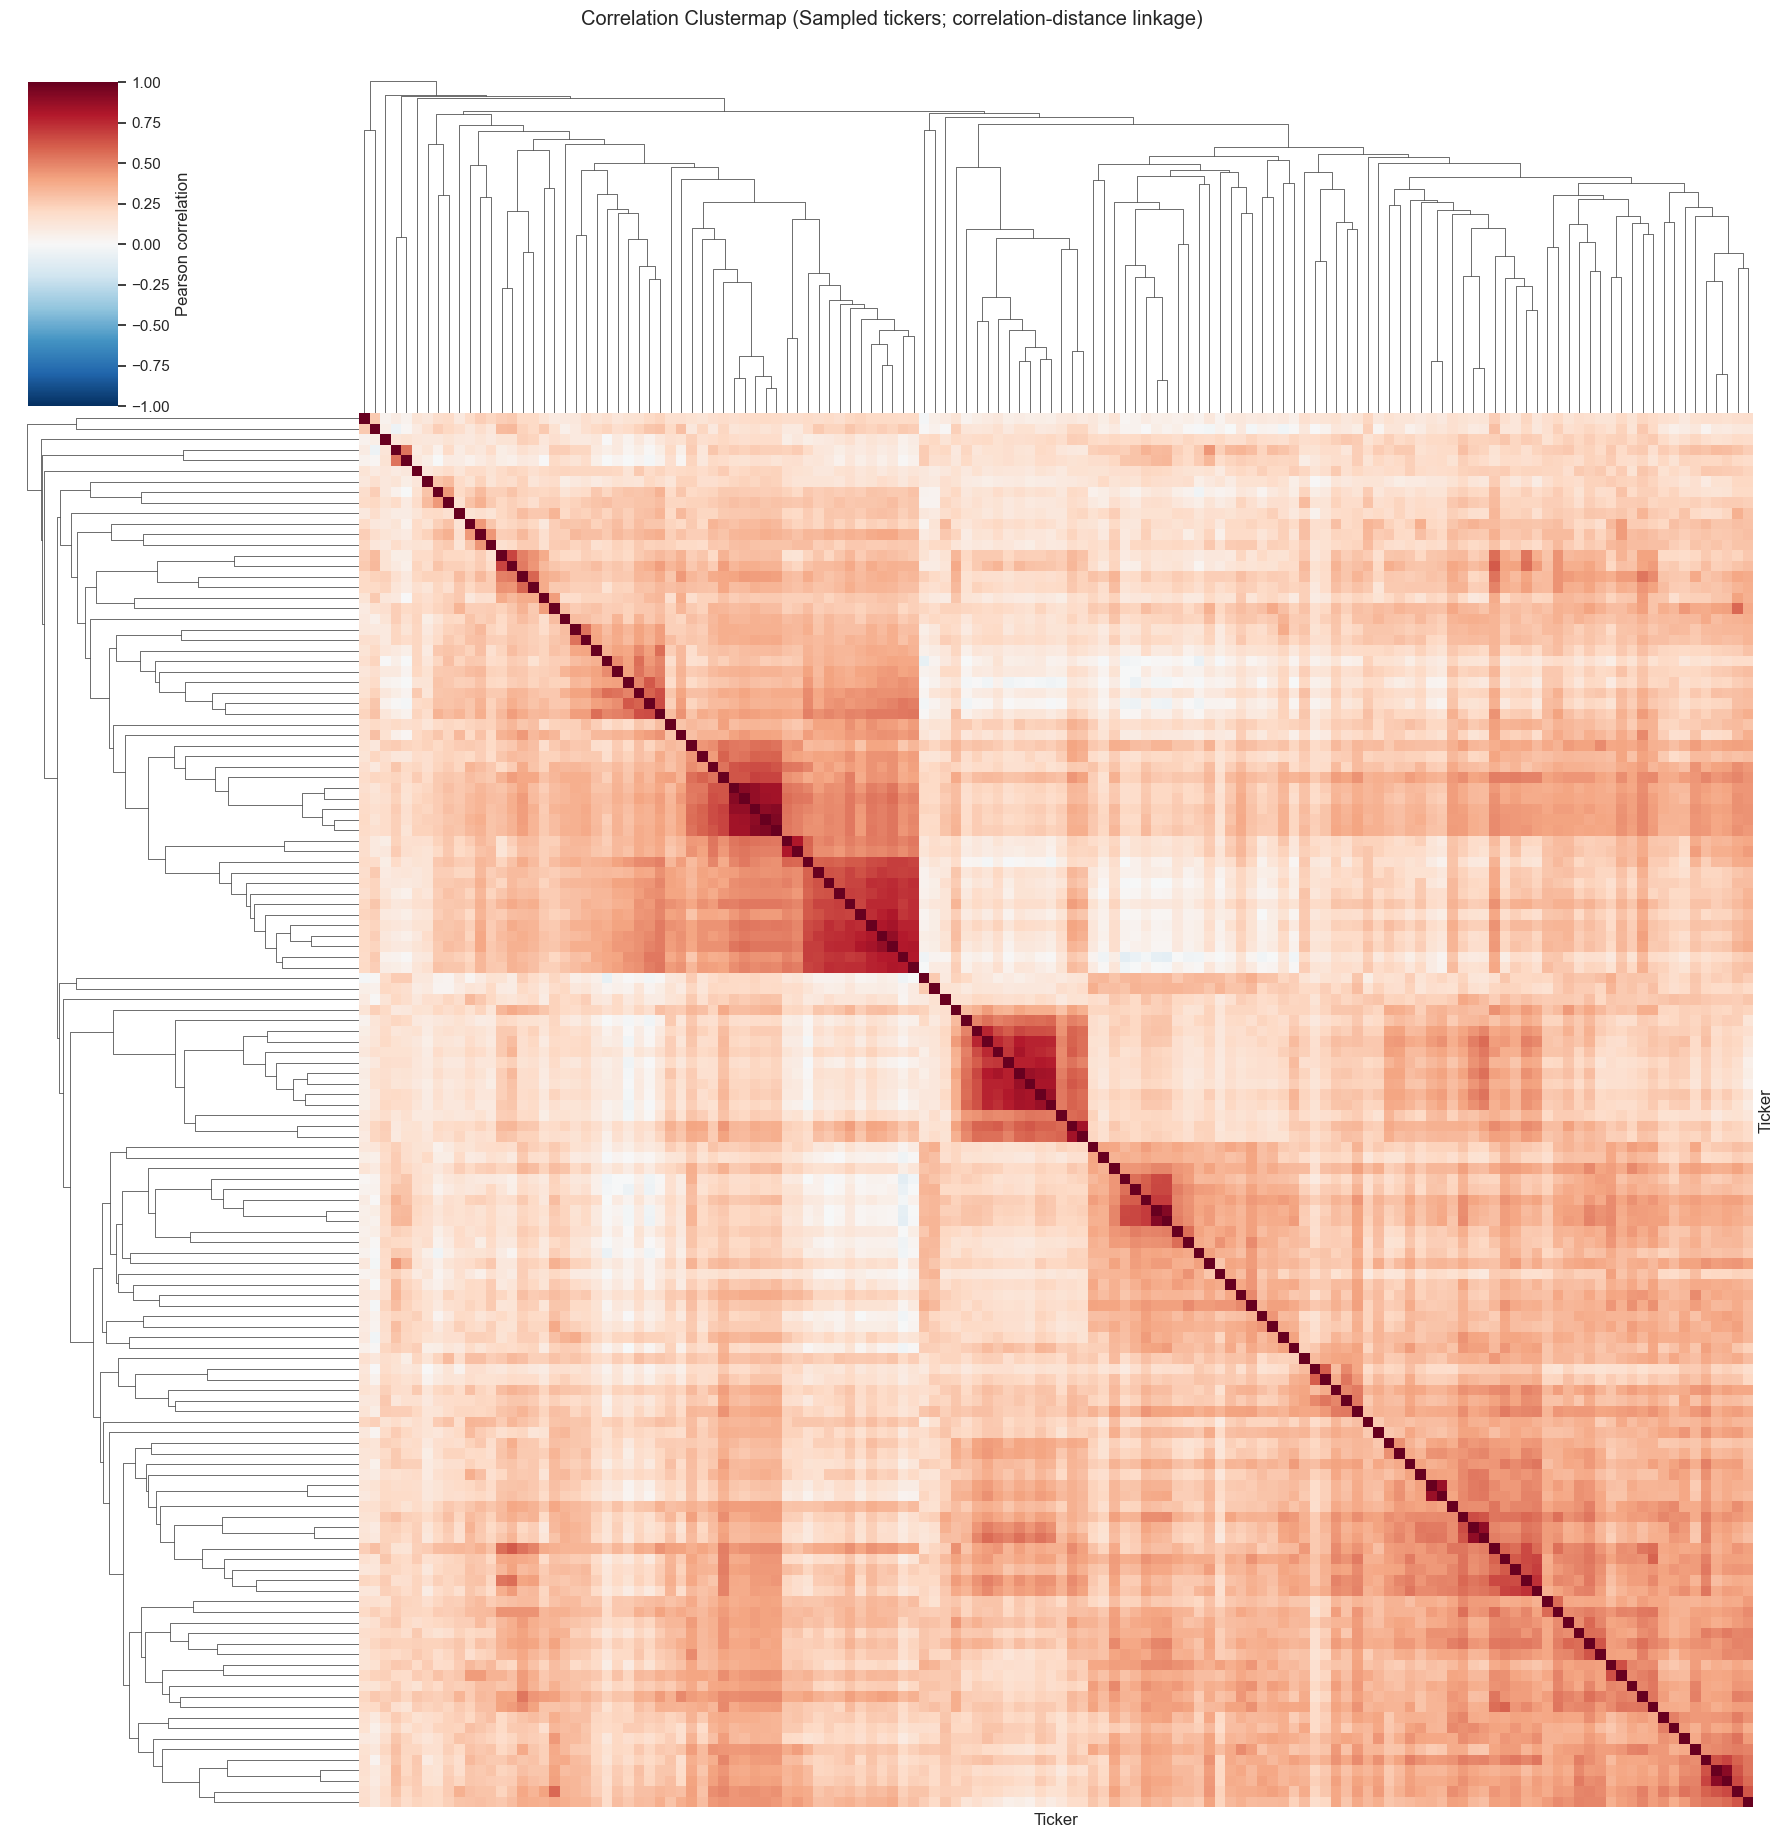

Anti-correlators (most negative correlation): CRWD vs GIS, corr=-0.166


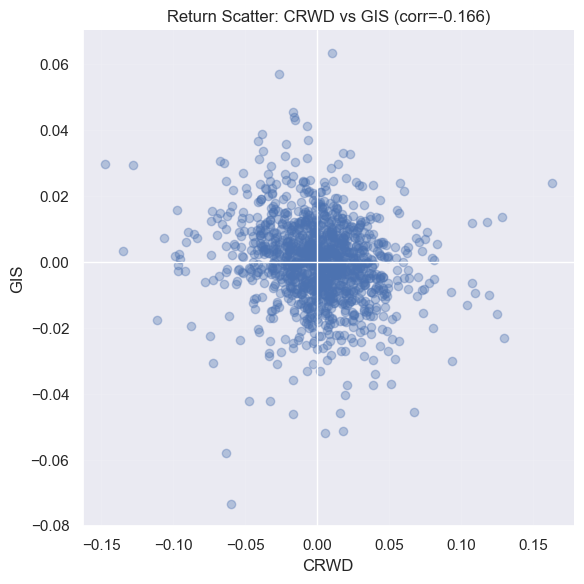

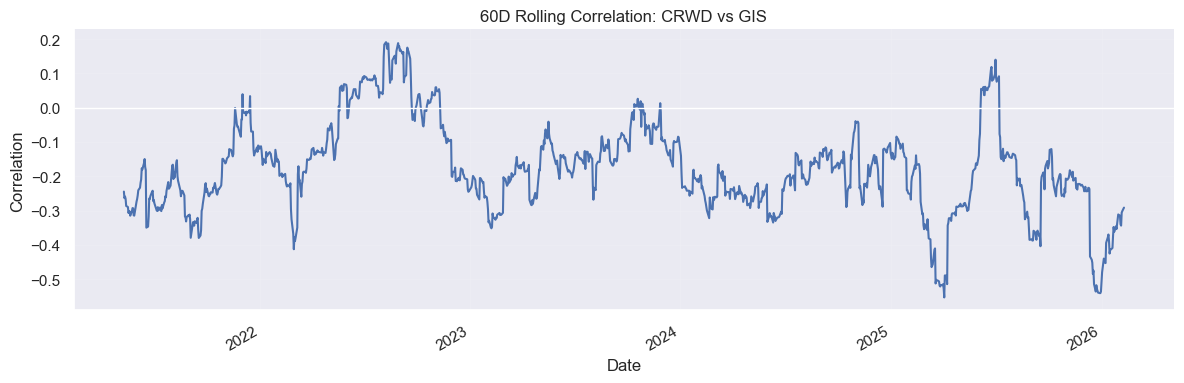

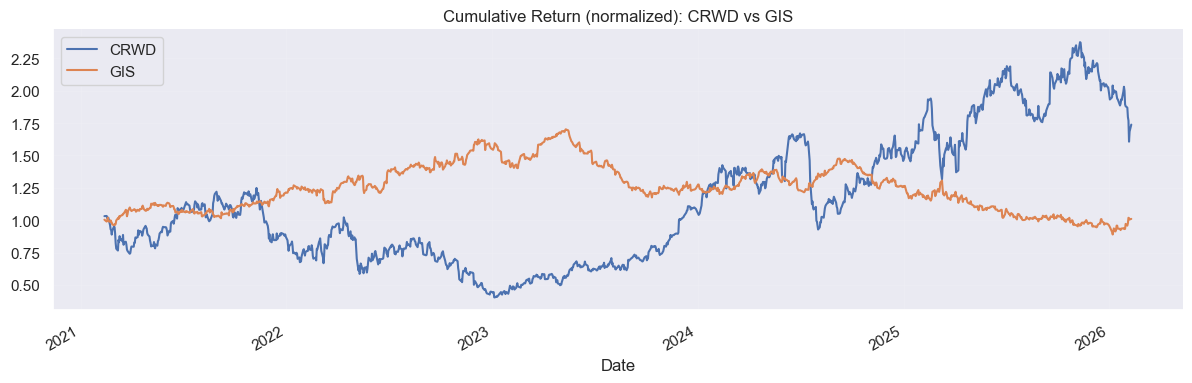

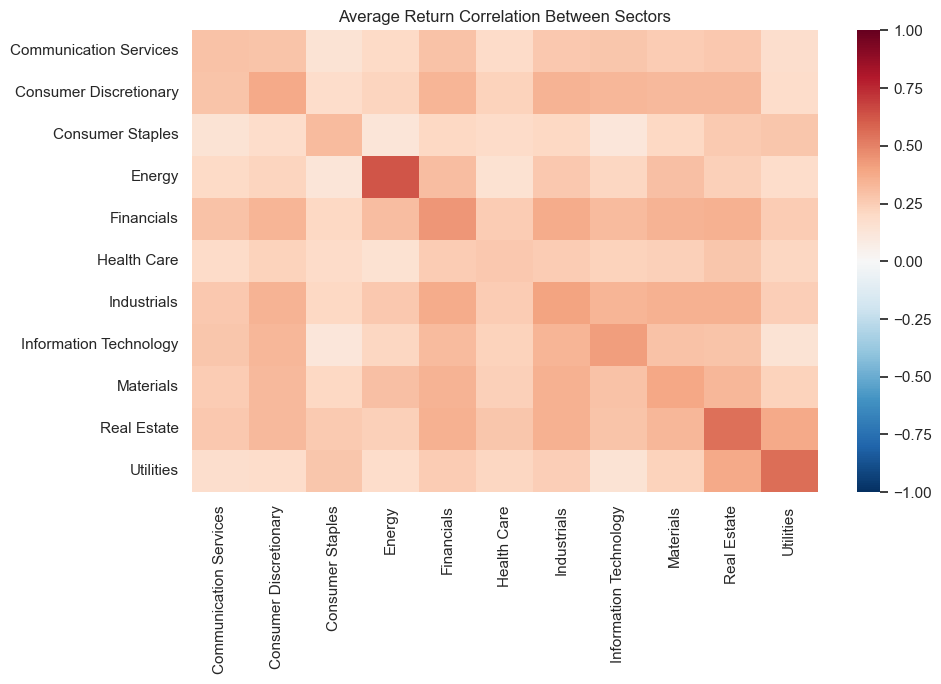

In [8]:
########## Write your code in this cell ############
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage

# -----------------------------
# PART 3 — CORRELATION & HIERARCHICAL STRUCTURE
# -----------------------------

# 0) Preconditions
assert "prices" in globals(), "Run Part 1 first (needs 'prices')."
assert "ticker_to_sector" in globals(), "Run Part 1 first (needs 'ticker_to_sector')."

# 1) Returns
returns = prices.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all")
returns = returns.dropna(axis=0, how="any")  # keep only complete days

# Drop constant/near-constant return columns (correlation undefined)
std = returns.std()
returns = returns.loc[:, std > 1e-12]

print("Returns shape used for correlation:", returns.shape)

# 2) Full correlation matrix (this is the core Part 3 object)
corr = returns.corr(method="pearson")
print("Correlation matrix shape:", corr.shape)
print("corr min/max:", float(corr.min().min()), float(corr.max().max()))

# 3) Make a readable clustermap by sampling tickers per sector
#    (Full 400–500 clustermap is technically valid but visually unusable.)
sectors = sorted({ticker_to_sector.get(t, "Unknown") for t in returns.columns})
sector_to_tickers = {
    s: [t for t in returns.columns if ticker_to_sector.get(t, "Unknown") == s]
    for s in sectors
}

rng = np.random.default_rng(42)
MAX_PER_SECTOR = 12

sampled = []
for s in sectors:
    tick_list = sector_to_tickers[s]
    if len(tick_list) == 0:
        continue
    k = min(MAX_PER_SECTOR, len(tick_list))
    sampled.extend(list(rng.choice(tick_list, size=k, replace=False)))

sampled = sorted(set(sampled))
print(f"Sampled {len(sampled)} tickers for clustermap across {len(sectors)} sectors.")

# Linkage based on correlation distance of return time series
# distance(i,j) = 1 - corr(ri, rj)
dist = pdist(returns[sampled].T, metric="correlation")
link = linkage(dist, method="average")

corr_sub = corr.loc[sampled, sampled]

g = sns.clustermap(
    corr_sub,
    row_linkage=link,
    col_linkage=link,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    figsize=(18, 18),
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Pearson correlation"}
)
g.fig.suptitle("Correlation Clustermap (Sampled tickers; correlation-distance linkage)", y=1.02)
plt.show()

# 4) Anti-correlators (full universe)
upper_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(upper_mask).stack().dropna()

neg_pairs = pairs[pairs < 0].sort_values()
if len(neg_pairs) > 0:
    (a, b) = neg_pairs.index[0]
    rho = float(neg_pairs.iloc[0])
    reason = "most negative correlation"
else:
    (a, b) = pairs.sort_values().index[0]
    rho = float(pairs.sort_values().iloc[0])
    reason = "lowest correlation (no negatives found)"

print(f"Anti-correlators ({reason}): {a} vs {b}, corr={rho:.3f}")

# Scatter of returns
plt.figure(figsize=(6, 6))
plt.scatter(returns[a], returns[b], alpha=0.35)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title(f"Return Scatter: {a} vs {b} (corr={rho:.3f})")
plt.xlabel(a)
plt.ylabel(b)
plt.tight_layout()
plt.show()

# Rolling correlation
roll_corr = returns[a].rolling(60).corr(returns[b])
plt.figure(figsize=(12, 4))
roll_corr.plot()
plt.axhline(0, linewidth=1)
plt.title(f"60D Rolling Correlation: {a} vs {b}")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# (Optional but interpretable) Cumulative returns comparison
cum_a = (1 + returns[a]).cumprod()
cum_b = (1 + returns[b]).cumprod()
plt.figure(figsize=(12, 4))
cum_a.plot(label=a)
cum_b.plot(label=b)
plt.title(f"Cumulative Return (normalized): {a} vs {b}")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Sector × sector average correlation heatmap (compact “tribes” view)
sector_corr = pd.DataFrame(index=sectors, columns=sectors, dtype=float)

for s1 in sectors:
    t1 = sector_to_tickers[s1]
    for s2 in sectors:
        t2 = sector_to_tickers[s2]
        if len(t1) == 0 or len(t2) == 0:
            sector_corr.loc[s1, s2] = np.nan
            continue

        block = corr.loc[t1, t2].values
        if s1 == s2:
            # exclude diagonal (self-correlation = 1)
            if block.shape[0] > 1:
                vals = block[np.triu_indices_from(block, k=1)]
            else:
                vals = np.array([])
        else:
            vals = block.ravel()

        sector_corr.loc[s1, s2] = np.nanmean(vals) if vals.size else np.nan

plt.figure(figsize=(10, 7))
sns.heatmap(sector_corr.astype(float), annot=False, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Average Return Correlation Between Sectors")
plt.tight_layout()
plt.show()


## Part 4: The Market Map: Dimensionality Reduction (PCA & t-SNE)

**The Objective:** 
This is where we enter the "Black Magic" of quantitative research. Currently, your dataset has over 1000 dimensions (one for every every market day) and about 500 rows (one for every stock. If this is not yet the case, transpose your dataset). As humans, we cannot visualize 1000+-dimensional space. To find the "latent" structure of the market, we must use **Dimensionality Reduction**.

We will use two primary tools:
1.  **PCA (Principal Component Analysis)** PCA may tell us what percentage of the market's movement is driven by a single "Market Factor" (The first Principal Component).
2.  **t-SNE (t-Distributed Stochastic Neighbor Embedding) or UMAP:** Non-linear techniques that are incredibly powerful for visualization. They attempt to keep "similar" stocks close together in 2D space, effectively creating a "Topographical Map" of the S&P 500.

### Your Tasks:
1.  **The Scree Plot:** Run PCA on your normalized returns. Plot the "Explained Variance Ratio." How many "components" does it take to explain 50% of the market's movement?
2.  **The 2D Projection:** Use **t-SNE** (or UMAP) to project the ~500 stocks into a 2-dimensional scatter plot. 
3.  **The Sector Overlay:** Color-code the dots in your scatter plot by their **GICS Sector** (Information Technology, Energy, etc.). 
4.  **Identify the Outliers:** Annotate the map (such that the name of a stock is revealed when the mouse hovers over it). Find the stocks that are "Socially Distancing" i.e. those that sit far away from their sector peers or in the middle of a different cluster entirely.

### Critical Thinking Questions:
*   **The Market Factor:** In your PCA analysis, you will likely find that the first component (PC1) explains a massive amount of variance. What do you think PC1 represents in the real world? (Hint: If every stock goes down at the same time, what is that called?)*   **Portfolios:** How would a portfolio based on PC1 be advantageous compared to a portfolio based on PC2 ? How would a portfolio based on PC2 be advantageous compared to a portfolio based on PC1 ? (Hint: think in terms of variance) 
*   **Linear vs. Non-Linear:** Compare your correlation clustermap from Part 3 with your t-SNE map here. Which one makes it easier to spot "anomalous" companies that don't belong with their peers?
*   **The "Misplaced" Stock:** If you see a "Technology" stock sitting deep inside the "Healthcare" cluster in your 2D map, does that necessarily mean your code is wrong, or is the market telling you something about that company's actual revenue stream?

---

Returns shape: (1253, 496)
PCA components for 50% variance: 35
PCA components for 80% variance: 145


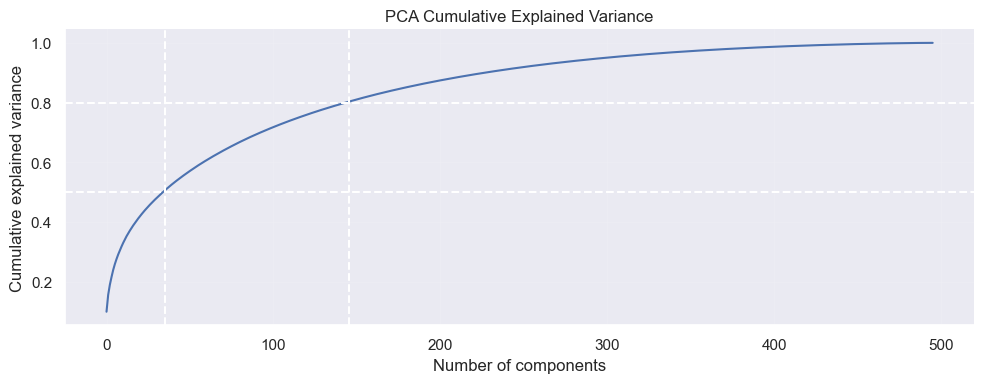

Top 15 sector outliers (largest distance to sector centroid):


,ticker,sector,dist_to_sector
227,HST,Real Estate,44.374657
78,CBRE,Real Estate,40.409008
486,WY,Real Estate,39.098003
467,VST,Utilities,34.779125
83,CEG,Utilities,34.777897
333,NRG,Utilities,34.771000
327,NEM,Materials,33.203045
57,BG,Consumer Staples,30.939442
9,ADM,Consumer Staples,30.859550
84,CF,Materials,24.987392


In [9]:
########## Write your code in this cell ############
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import plotly.express as px


# -----------------------------
# PART 4 — DIMENSIONALITY REDUCTION: PCA + t-SNE
# -----------------------------

# 0) Preconditions
assert "prices" in globals(), "Run Part 1 first (needs 'prices')."
assert "ticker_to_sector" in globals(), "Run Part 1 first (needs 'ticker_to_sector')."

# 1) Compute returns (features over time)
returns = prices.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all")
returns = returns.dropna(axis=0, how="any")

# Drop constant/near-constant columns to avoid degenerate behavior
std = returns.std()
returns = returns.loc[:, std > 1e-12]

print("Returns shape:", returns.shape)

# 2) Build stock-by-day matrix: rows = stocks, columns = days
X = returns.T  # (n_stocks, n_days)

tickers_used = X.index.tolist()
sectors_used = [ticker_to_sector.get(t, "Unknown") for t in tickers_used]

# Ensure numeric matrix (should already be numeric)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# 3) Standardize features (days)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

# -----------------------------
# PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

expl = pca.explained_variance_ratio_
cum = np.cumsum(expl)

# How many components explain 50% and 80% of variance?
k50 = int(np.argmax(cum >= 0.50) + 1)
k80 = int(np.argmax(cum >= 0.80) + 1)
print(f"PCA components for 50% variance: {k50}")
print(f"PCA components for 80% variance: {k80}")

# Scree / cumulative explained variance plot
plt.figure(figsize=(10, 4))
plt.plot(cum)
plt.axhline(0.50, linestyle="--")
plt.axhline(0.80, linestyle="--")
plt.axvline(k50, linestyle="--")
plt.axvline(k80, linestyle="--")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()

# Optional: 2D PCA scatter (often helpful to compare with t-SNE)
pca2 = PCA(n_components=2, random_state=42)
Z_pca2 = pca2.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "ticker": tickers_used,
    "sector": sectors_used,
    "pc1": Z_pca2[:, 0],
    "pc2": Z_pca2[:, 1],
})

fig = px.scatter(
    pca_df,
    x="pc1", y="pc2",
    color="sector",
    hover_name="ticker",
    title="PCA (2D) Market Map (normalized returns)"
)
fig.show()


# -----------------------------
# t-SNE (use PCA pre-reduction for stability & speed)
# -----------------------------
# Pre-reduce to at most 50 PCs (or smaller if you have fewer stocks/days)
n_pre = min(50, X_scaled.shape[1], X_scaled.shape[0] - 1)
pca_pre = PCA(n_components=n_pre, random_state=42)
X_pre = pca_pre.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)
Z_tsne = tsne.fit_transform(X_pre)

tsne_df = pd.DataFrame({
    "ticker": tickers_used,
    "sector": sectors_used,
    "x": Z_tsne[:, 0],
    "y": Z_tsne[:, 1],
})

fig = px.scatter(
    tsne_df,
    x="x", y="y",
    color="sector",
    hover_name="ticker",
    title="t-SNE Market Map (on PCA-preduced, normalized returns)"
)
fig.show()


# -----------------------------
# “Socially distancing” outliers: far from sector centroid in t-SNE space
# -----------------------------
centroids = tsne_df.groupby("sector")[["x", "y"]].mean()
tsne_df = tsne_df.join(centroids, on="sector", rsuffix="_c")

tsne_df["dist_to_sector"] = np.sqrt(
    (tsne_df["x"] - tsne_df["x_c"])**2 + (tsne_df["y"] - tsne_df["y_c"])**2
)

print("Top 15 sector outliers (largest distance to sector centroid):")
display(tsne_df.sort_values("dist_to_sector", ascending=False)[["ticker", "sector", "dist_to_sector"]].head(15))


In [ ]:
#ZiqiaoTang100001270